In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Grafik-Stil für professionelle Plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# 1. PARAMETER
WINDOW_LEN = 170
INPUT_TRAIN = 'training_data_nan_bereinigt.csv'
INPUT_TEST = 'test_data_nan_bereinigt.csv'
MODEL_FILE = 'sonar_model_final.pkl'

print("Bibliotheken geladen. Umgebung bereit.")

Bibliotheken geladen. Umgebung bereit.


In [71]:
def natural_sort_key(s):
    """
    Sortiert Strings natürlich (S_2 vor S_10), damit die Zeitachse stimmt.
    """
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('(\d+)', s)]


def process_signal_fast(sig, win_len, p_mask, v_start):
    """
    Python-Implementierung der Matlab-Logik (Peak/Valley Search & Windowing).
    """
    sig_len = len(sig)

    # 1. Global Peak Search (maskiert)
    roi_start = min(sig_len, p_mask)
    if roi_start >= sig_len:
        peak_idx = 0
    else:
        # argmax auf dem Slice -> relativer Index -> + roi_start
        peak_idx = roi_start + np.argmax(sig[roi_start:])

    peak_val_raw = sig[peak_idx] if peak_idx < sig_len else 0

    # 2. Valley Search
    v_s = min(sig_len, v_start)
    v_e = peak_idx

    if v_s >= v_e:
        valley_idx = v_s
    else:
        valley_idx = v_s + np.argmin(sig[v_s:v_e])

    valley_val = sig[valley_idx] if valley_idx < sig_len else 0

    # 3. Onset Detection (10% Threshold)
    threshold = valley_val + (peak_val_raw - valley_val) * 0.10
    rise_segment = sig[valley_idx:peak_idx] if valley_idx < peak_idx else np.array([
    ])

    if len(rise_segment) == 0:
        onset_abs = valley_idx
    else:
        below_idx = np.where(rise_segment < threshold)[0]
        # Letzter Punkt unter Threshold
        onset_abs = valley_idx + (below_idx[-1] if len(below_idx) > 0 else 0)

    # 4. Fenster ausschneiden (Alignment)
    start_idx = onset_abs
    end_idx = start_idx + win_len
    aligned_window = np.zeros(win_len)

    # Safe Slicing mit Index-Checks
    read_start = max(0, start_idx)
    read_end = min(sig_len, end_idx)
    write_start = read_start - start_idx
    write_end = write_start + (read_end - read_start)

    if read_start < read_end and write_start < win_len:
        aligned_window[write_start:write_end] = sig[read_start:read_end]

    # 5. Features berechnen
    raw_energy = np.sum(aligned_window**2)
    s_val = np.std(aligned_window)
    m_val = np.mean(aligned_window)

    # Z-Score Normalisierung im Fenster
    if s_val > 1e-9:
        aligned_window_norm = (aligned_window - m_val) / s_val
    else:
        aligned_window_norm = aligned_window - m_val

    # Peak Position im Fenster
    loc = peak_idx - start_idx
    loc = max(0, min(win_len - 1, loc))
    peak_norm = aligned_window_norm[loc]

    # Breite (FWHM)
    half_val = peak_norm * 0.5

    # Links suchen
    left_part = aligned_window_norm[:loc]
    left_idxs = np.where(left_part < half_val)[0]
    left_idx = left_idxs[-1] if len(left_idxs) > 0 else 0

    # Rechts suchen
    right_part = aligned_window_norm[loc:]
    right_idxs = np.where(right_part < half_val)[0]
    width_idx = (loc + right_idxs[0]) if len(right_idxs) > 0 else (win_len - 1)

    width = width_idx - left_idx

    return [raw_energy, peak_val_raw, peak_norm, width], aligned_window_norm


def load_and_extract(filename, win_len):
    """Lädt CSV, bereinigt NaNs, sortiert Spalten und extrahiert Features."""
    # 1. Laden
    try:
        df = pd.read_csv(filename, sep=';')
    except:
        df = pd.read_csv(filename, sep=',')  # Fallback

    df.columns = df.columns.str.strip()

    # 2. NaN Behandlung (Kritisch!)
    if df.isna().sum().sum() > 0:
        print(f"Hinweis: NaNs in {filename} gefunden. Werden mit 0 gefüllt.")
        df.fillna(0, inplace=True)

    # 3. Split & Sort High/Low
    df_high = df[df['Frequency'].str.lower(
    ) == 'high'].copy().sort_values('Timestamp')
    df_low = df[df['Frequency'].str.lower(
    ) == 'low'].copy().sort_values('Timestamp')

    n = min(len(df_high), len(df_low))
    df_high = df_high.iloc[:n]
    df_low = df_low.iloc[:n]

    # 4. Spalten identifizieren & SORTIEREN
    hf_cols = sorted(
        [c for c in df_high.columns if c.startswith('S_')], key=natural_sort_key)
    lf_cols = sorted(
        [c for c in df_low.columns if c.startswith('S_')], key=natural_sort_key)

    data_hf = df_high[hf_cols].values
    data_lf = df_low[lf_cols].values
    labels = df_high['class_name'].values

    # 5. Extraction Loop
    num_samples = len(labels)
    # 8 Stats (4 HF + 4 LF) + 2 Waveforms (HF + LF)
    num_features = 8 + 2 * win_len
    X = np.zeros((num_samples, num_features))

    print(f"Extrahiere Features aus {filename} ({num_samples} Samples)...")
    for i in range(num_samples):
        # High Frequency (Maske 30, Start 20)
        stats_hf, win_hf = process_signal_fast(data_hf[i], win_len, 30, 20)
        # Low Frequency (Maske 78, Start 55)
        stats_lf, win_lf = process_signal_fast(data_lf[i], win_len, 78, 55)

        X[i, :] = np.concatenate([stats_hf, stats_lf, win_hf, win_lf])

    # Geben Rohdaten (data_hf) für Visualisierung zurück
    return X, labels, data_hf

In [72]:
def visualize_signal_processing(sig, win_len, p_mask, v_start, label_name="Signal"):
    """
    Visualisiert exakt, wo Peak, Valley und Onset gefunden wurden.
    Hilft zu verstehen, warum bestimmte Signale gut/schlecht erkannt werden.
    """
    # Logik wiederholen für Plot-Koordinaten
    sig_len = len(sig)
    roi_start = min(sig_len, p_mask)
    peak_idx = roi_start + \
        np.argmax(sig[roi_start:]) if roi_start < sig_len else 0
    peak_val = sig[peak_idx]

    v_s = min(sig_len, v_start)
    valley_idx = v_s + np.argmin(sig[v_s:peak_idx]) if v_s < peak_idx else v_s
    valley_val = sig[valley_idx]

    threshold = valley_val + (peak_val - valley_val) * 0.10
    rise_segment = sig[valley_idx:peak_idx]
    below_idx = np.where(rise_segment < threshold)[0]
    onset_abs = valley_idx + (below_idx[-1] if len(below_idx) > 0 else 0)

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(sig, color='#7f8c8d', alpha=0.6, label='Raw Signal')

    # Keypoints
    plt.plot(peak_idx, peak_val, 'rx', markersize=10,
             markeredgewidth=2, label='Peak')
    plt.plot(valley_idx, valley_val, 'bv', markersize=10, label='Valley')
    plt.plot(onset_abs, sig[onset_abs], 'go',
             markersize=8, label='Onset (Cut)')

    # Fenster Bereich
    plt.axvspan(onset_abs, onset_abs + win_len, color='#2ecc71',
                alpha=0.2, label='Extracted Window')
    plt.hlines(threshold, valley_idx, peak_idx, colors='orange',
               linestyles='--', label='10% Threshold')

    plt.title(f"Processing Detail: {label_name}")
    plt.legend()
    plt.show()

Hinweis: NaNs in training_data_nan_bereinigt.csv gefunden. Werden mit 0 gefüllt.
Extrahiere Features aus training_data_nan_bereinigt.csv (54 Samples)...
Hinweis: NaNs in test_data_nan_bereinigt.csv gefunden. Werden mit 0 gefüllt.
Extrahiere Features aus test_data_nan_bereinigt.csv (18 Samples)...

--- Visualisierung A: Exemplarisches Signal-Processing ---


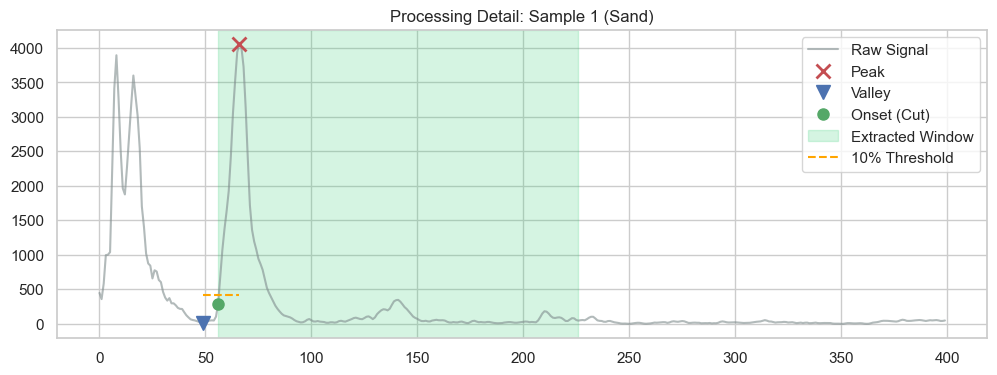


--- Visualisierung B: Durchschnittliche Wellenformen pro Klasse ---


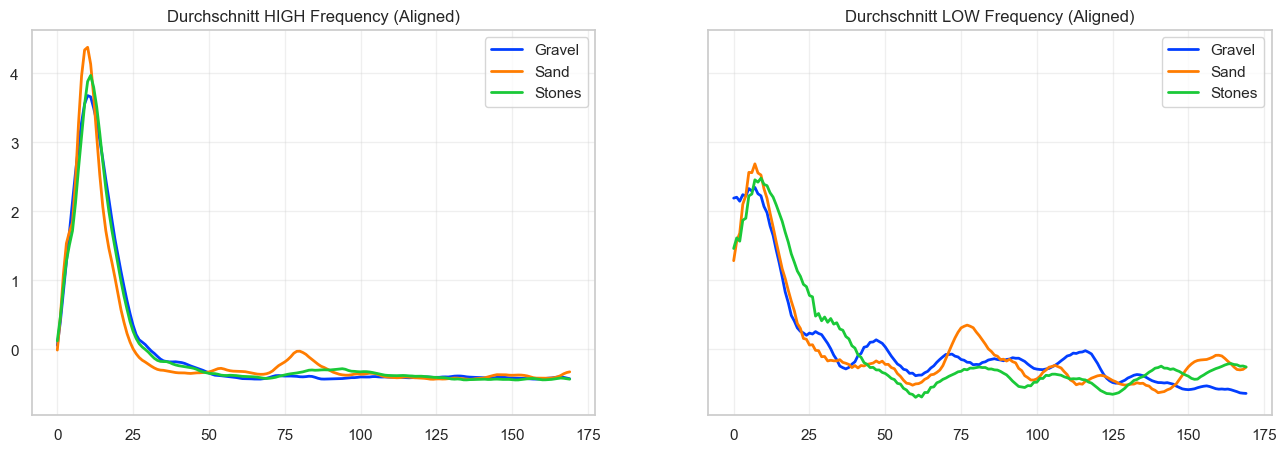

In [73]:
# 1. Daten laden
if os.path.exists(INPUT_TRAIN) and os.path.exists(INPUT_TEST):
    # Wir laden auch die Roh-Signale (raw_sig_hf) für die Demo-Visualisierung
    X_train_raw, Y_train, raw_sig_hf = load_and_extract(
        INPUT_TRAIN, WINDOW_LEN)
    X_test_raw, Y_test, _ = load_and_extract(INPUT_TEST, WINDOW_LEN)
else:
    raise FileNotFoundError("Input Files fehlen!")

# 2. Visualisierung A: Exemplarische Verarbeitung (Erstes Sample)
print("\n--- Visualisierung A: Exemplarisches Signal-Processing ---")
visualize_signal_processing(
    raw_sig_hf[0], WINDOW_LEN, 30, 20, f"Sample 1 ({Y_train[0]})")

# 3. Visualisierung B: Durchschnittliche Signale pro Klasse
print("\n--- Visualisierung B: Durchschnittliche Wellenformen pro Klasse ---")
classes = np.unique(Y_train)
# Indizes im Feature Vektor: 8 Stats, dann 170 HF, dann 170 LF
hf_start, hf_end = 8, 8 + WINDOW_LEN
lf_start, lf_end = 8 + WINDOW_LEN, 8 + 2 * WINDOW_LEN

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
colors = sns.color_palette("bright", len(classes))

for i, cls in enumerate(classes):
    mask = (Y_train == cls)
    # Durchschnitt berechnen
    mean_hf = np.mean(X_train_raw[mask, hf_start:hf_end], axis=0)
    mean_lf = np.mean(X_train_raw[mask, lf_start:lf_end], axis=0)

    axes[0].plot(mean_hf, label=cls, color=colors[i], linewidth=2)
    axes[1].plot(mean_lf, label=cls, color=colors[i], linewidth=2)

axes[0].set_title("Durchschnitt HIGH Frequency (Aligned)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Durchschnitt LOW Frequency (Aligned)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()

In [ ]:
# Feature Split
NUM_STATS = 8
X_stats_train = X_train_raw[:, :NUM_STATS]
X_wave_train = X_train_raw[:, NUM_STATS:]
X_stats_test = X_test_raw[:, :NUM_STATS]
X_wave_test = X_test_raw[:, NUM_STATS:]

# 1. Standardisierung (Z-Score)
scaler = StandardScaler()
X_wave_train_std = scaler.fit_transform(X_wave_train)
X_wave_test_std = scaler.transform(X_wave_test)

# 2. PCA mit genau 24% Varianz
print("Berechne PCA...")
pca = PCA(n_components=0.24, random_state=42)
X_pca_train = pca.fit_transform(X_wave_train_std)
X_pca_test = pca.transform(X_wave_test_std)

print(f"   -> {pca.n_components_} Komponenten erklären {np.sum(pca.explained_variance_ratio_)*100:.1f}% Varianz.")

# Features kombinieren
X_train_final = np.hstack([X_stats_train, X_pca_train])
X_test_final = np.hstack([X_stats_test, X_pca_test])

# 3. Training (Random Forest)
print("Trainiere Random Forest (300 Trees)...")
model = RandomForestClassifier(n_estimators=300,
                               random_state=42,
                               max_features='sqrt',
                               min_samples_leaf=1)
model.fit(X_train_final, Y_train)
print("Training abgeschlossen.")

Berechne PCA (Ziel: 24% Varianz)...
   -> 2 Komponenten erklären 24.2% Varianz.
Trainiere Random Forest (300 Trees)...
Training abgeschlossen.


GENAUIGKEIT (Testset): 83.3%


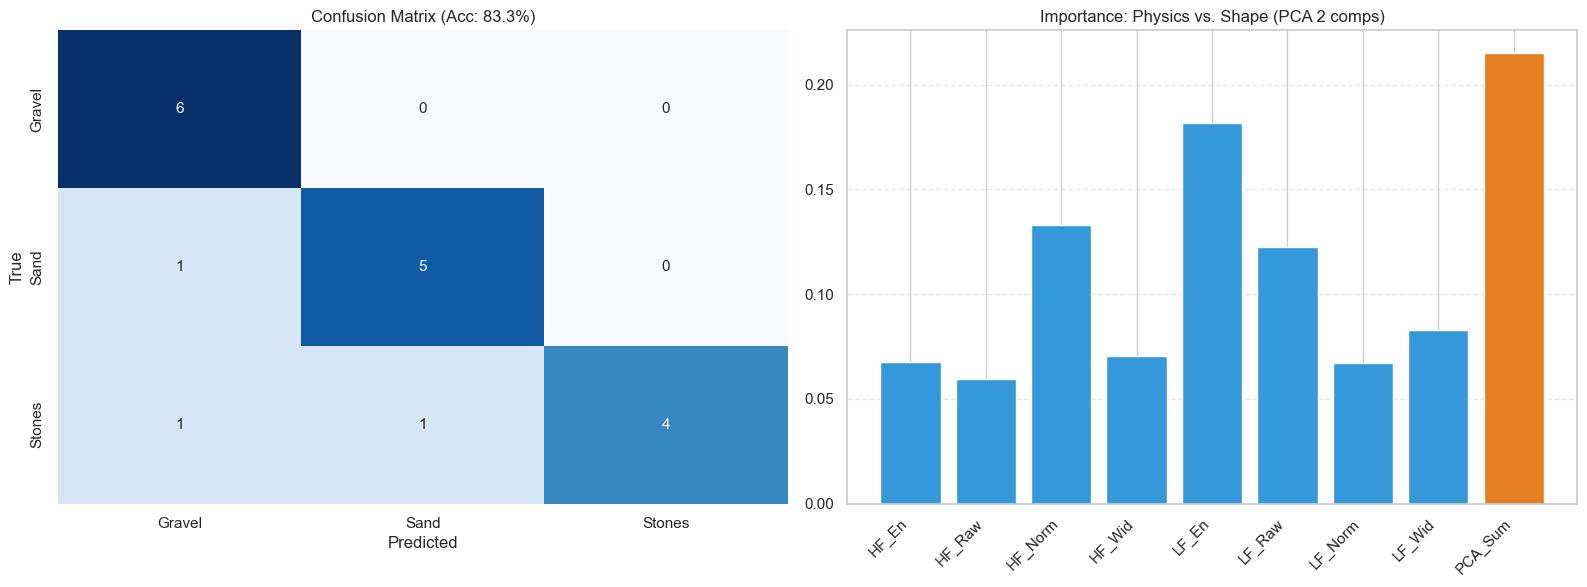

Modell gespeichert als 'sonar_model_final.pkl'


In [75]:
# Prediction
Y_pred = model.predict(X_test_final)
acc = accuracy_score(Y_test, Y_pred)

print("================================================")
print(f"GENAUIGKEIT (Testset): {acc * 100:.1f}%")
print("================================================")

# Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=np.unique(Y_train), yticklabels=np.unique(Y_train))
axes[0].set_title(f"Confusion Matrix (Acc: {acc*100:.1f}%)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Feature Importance
imps = model.feature_importances_
imp_stats = imps[:8]           # Die 8 physikalischen Stats
imp_pca_sum = np.sum(imps[8:])  # Summe aller PCA Komponenten

labels = ['HF_En', 'HF_Raw', 'HF_Norm', 'HF_Wid',
          'LF_En', 'LF_Raw', 'LF_Norm', 'LF_Wid',
          'PCA_Sum']
values = np.append(imp_stats, imp_pca_sum)
colors = ['#3498db']*8 + ['#e67e22']  # Blau=Physik, Orange=Form

axes[1].bar(labels, values, color=colors)
axes[1].set_title(
    f"Importance: Physics vs. Shape (PCA {pca.n_components_} comps)")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Speichern
joblib.dump({'model': model, 'pca': pca,
            'scaler': scaler, 'acc': acc}, MODEL_FILE)
print(f"Modell gespeichert als '{MODEL_FILE}'")